In [ ]:
import numpy as numpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
# for analysis
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans

In [3]:
# lib for text analysis
import re
import nltk
import contractions
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from wordcloud import WordCloud
from collections import Counter
from textblob import TextBlob



In [4]:
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/andyzheng/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /Users/andyzheng/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andyzheng/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/andyzheng/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [49]:
df = pd.read_csv('data/IL_review.csv')
df2 = pd.read_csv("data/IL_business.csv")

df = pd.merge(df, df2, on='business_id', how='left')

In [23]:
df.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,Ad91EzbAGRCR1SwkPfZJKg,LWTvg7RlyNLXIf482tXBPw,WCVFqK84i2H5EClSoow7ZA,5,0,0,0,"Traveling through in our RV, stopped over in G...",2016-07-21T17:41:18Z
1,uGJubhANtj6sfP_xz8LeLQ,1EecTw-Iojid62ySMMl5gA,xR3inMR2KceU3b9dhkz_tw,4,0,0,0,The food and service was amazing! I only wish ...,2016-01-30T04:15:18Z
2,xqp0pnO0PfBkaFRNaVImYw,c35f8FumQy5045zFbIir6w,_uyLoz0BbrQIVmUEm_td1Q,3,0,0,0,My husband had the 6 oz pepperloin meal and wa...,2018-06-09T01:10:44Z
3,9YtDeiEdfrnRj1ykyp7Utw,FP7w-DB7x_cFovMdRbVCNw,JCWwQuH9pEHg-yTj4-D_ow,1,5,3,1,"You think Value City, you think cheap value, r...",2012-03-30T05:25:31Z
4,91uC4f0aX4ycQTDL5Hq7Mw,huHPQSQgw4kFakc0Vq7TDA,_D7QoWuQKMXk0mEE7r_Ftw,5,1,0,1,I have been a fan of Chateau La Vin for a few ...,2014-03-14T13:55:46Z


In [24]:
df.info(59)

<class 'pandas.DataFrame'>
RangeIndex: 51832 entries, 0 to 51831
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    51832 non-null  str  
 1   user_id      51832 non-null  str  
 2   business_id  51832 non-null  str  
 3   stars        51832 non-null  int64
 4   useful       51832 non-null  int64
 5   funny        51832 non-null  int64
 6   cool         51832 non-null  int64
 7   text         51832 non-null  str  
 8   date         51832 non-null  str  
dtypes: int64(4), str(5)
memory usage: 3.6 MB


In [28]:
df['date'] = pd.to_datetime (df['date'])


In [27]:
# check for missing data
df.isnull().sum()

review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64

In [30]:
# initiate Lemmaatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
#exclude negation words
negation = {'no', 'not', 'nor', 'never'}
stop_words = stop_words - negation
#add new stopwords you like
stop_words. update(['would', 'us', 'one'])



In [ ]:
df['cleaned_reviews']=df['text'].str.lower()

df['cleaned_reviews'] = df['cleaned_reviews'].apply(contractions.fix)
df['cleaned_reviews'] = df['cleaned_reviews'].str.replace(r'[^a-z\s]', '', regex = True) # remove special characters

df['cleaned_reviews'] = df['cleaned_reviews'].str.split().str.join(" ") # remove empty space 

In [32]:
df['tokenized_reviews'] = df['cleaned_reviews'].apply(word_tokenize)

In [33]:
#remove stopwords
df['tokenized_reviews'] = df['tokenized_reviews'].apply(lambda words: [word for word in words if word not in stop_words])

In [34]:
#lemmatization
df['tokenized_reviews'] = df['tokenized_reviews'].apply(lambda words : [lemmatizer.lemmatize(word) for word in words])

In [35]:
#combine all words from text (bag of words)
all_words = [word for words in df['tokenized_reviews'] for word in words]

In [36]:
# Count word frequencies 
word_freq = Counter(all_words) 

In [37]:
# Convert to DataFrame for visualization 
word_freq_df = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False) 


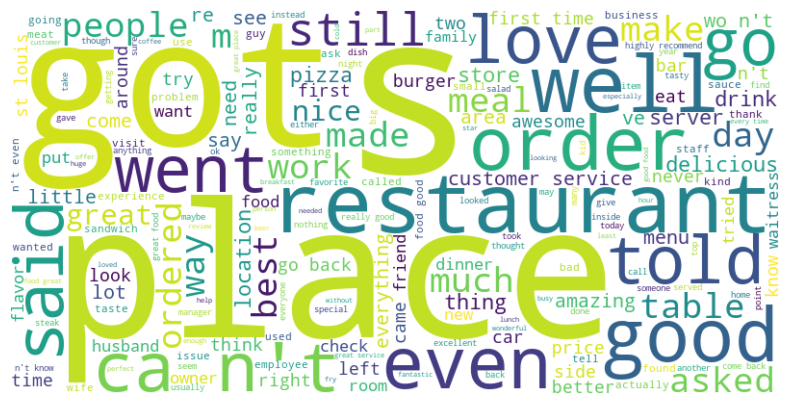

In [38]:
# Generate word cloud 
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(all_words)) 

# Display word cloud 
plt.figure(figsize=(10, 5)) 
plt.imshow(wordcloud, interpolation="bilinear") 
plt.axis("off") 
plt.show()


In [39]:
# Most VADER and TextBlob have built in tokenization and lemmatization 
# Because of this, we only need to use the cleaned_reviews text here

# Vader Analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyser = SentimentIntensityAnalyzer()

In [40]:
df['vader_sentiment'] = df['cleaned_reviews'].apply(
    lambda text:analyser.polarity_scores(text)['compound']
)

In [41]:
# TextBlob Analysis
df['blob_sentiment'] = df['cleaned_reviews'].apply(
    lambda text:TextBlob(text).sentiment.polarity
)

In [54]:
sentiment_output = df[['text', 'vader_sentiment', 'blob_sentiment']].copy()
#manually review and decide to use VADER sentiment scores

KeyError: "['vader_sentiment', 'blob_sentiment'] not in index"

In [52]:
#sentiment_output = df.groupby(['business_id'])[['vader_sentiment']].mean().reset_index()
sentiment_output.head(10)


,business_id,vader_sentiment
0,-0epFLgYq2C1Jo_W4FOBKw,0.754861
1,-1wnOZFsvsJPEXh_hWcmMA,0.804655
2,-2gmbMDzKgYZ_8DOnJtPyw,-0.006240
3,-6kNhGurAbdNQanqbAaoMg,0.431828
4,-78Va3llKcPbL6SW4is8lw,0.709050
5,-7_R1BNUukbvb97OMNmxnA,0.508654
6,-9Kxik9BRNkft5rPcVvSsw,0.131057
7,-9QWlFM3KH0DBS1wiHZJXA,0.265508
8,-Awb67JgBbySP4mQtOtNsA,0.346700
9,-CoSh2bjDUFPDPjPe43zXA,0.524625


In [55]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

df['sentiment'] = df['text'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

In [56]:
def label_sentiment(score):
    if score > 0.2:
        return 'Positive'
    elif score < -0.2:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment'].apply(label_sentiment)

In [57]:
df.groupby('city')['sentiment'].mean().sort_values(ascending=False)

city
Chicago                 0.959442
South Roxana            0.896067
Maryville               0.891895
St. Louis               0.831300
Rosewood Heights        0.794271
Hartford                0.716405
Scott Air Force Base    0.713966
East St Louis           0.710917
Waterloo                0.710265
Freeburg                0.690101
Dupo                    0.688785
Madison                 0.658916
Belleville              0.647686
Fairmont City           0.646643
Edwardsville            0.642311
Washington Park         0.633003
Columbia                0.627613
Alton                   0.621287
Lebanon                 0.615771
St Louis                0.611180
Godfrey                 0.604552
Maryville               0.603870
Foster Pond             0.579319
Troy                    0.577020
Millstadt               0.576584
Smithton                0.575066
Belleville              0.567415
Granite City            0.559244
East Alton              0.551628
O'fallon                0.546896
O'Fal

In [58]:
pd.crosstab(df['city'], df['sentiment_label'])

sentiment_label,Negative,Neutral,Positive
city,,,
Alton,512,139,2954
Belleville,1219,357,5986
Belleville,0,0,7
Bellville,4,0,2
Bethalto,16,7,71
Brooklyn,12,1,21
Cahokia,49,18,171
Caseyville,118,28,383
Centreville,10,0,12
